<a href="https://colab.research.google.com/github/fruct49/ml_practice/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

### 2. Импортируем датасет

In [2]:
!wget 'https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB' -O test.csv
!wget 'https://drive.google.com/uc?export=download&id=1oDzBtqrXFDnc4ABbAi5hy9UXXT5uVdbD' -O train.csv
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df.head()

--2026-05-15 19:54:54--  https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB
Resolving drive.google.com (drive.google.com)... 172.253.63.113, 172.253.63.102, 172.253.63.101, ...
Connecting to drive.google.com (drive.google.com)|172.253.63.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download [following]
--2026-05-15 19:54:54--  https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.167.132, 2607:f8b0:4004:c1d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.167.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28629 (28K) [application/octet-stream]
Saving to: ‘test.csv’

test.csv            100%[===================>]  27.96K  --.-KB/s    in 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [3]:
print("Информация о датасете:")
df.info()
print("\nСтатистическое описание:")
display(df.describe())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Статистическое описание:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4. Сформируем обучающую и тестовую выборки:


In [4]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

df = df.drop('Cabin', axis=1)

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"Размер обучающей: {X_train.shape}, Размер тестовой: {X_test.shape}")

Размер обучающей: (596, 11), Размер тестовой: (295, 11)


### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [5]:
cols_to_drop = ["Name", "Ticket", "PassengerId"]

X_train2 = X_train.drop(cols_to_drop, axis=1)
X_test2 = X_test.drop(cols_to_drop, axis=1)

print(f"Признаков после очистки: {X_train2.shape[1]}")
X_train2.head()

Признаков после очистки: 8


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
6,1,54.000000,0,0,51.8625,True,False,True
718,3,29.699118,0,0,15.5000,True,True,False
685,2,25.000000,1,2,41.5792,True,False,False
73,3,26.000000,1,0,14.4542,True,False,False
882,3,22.000000,0,0,10.5167,False,False,True


### 6. Построение базовой модели:

In [6]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_test2)

### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [7]:
def vcm(y_pred, y_test):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True)
    plt.title('Матрица ошибок')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Реальные значения')
    plt.show()

    print("Отчет классификации:")
    print(classification_report(y_test, y_pred))

#### 7.2. Оцените точность модели:

(295,) (295,)


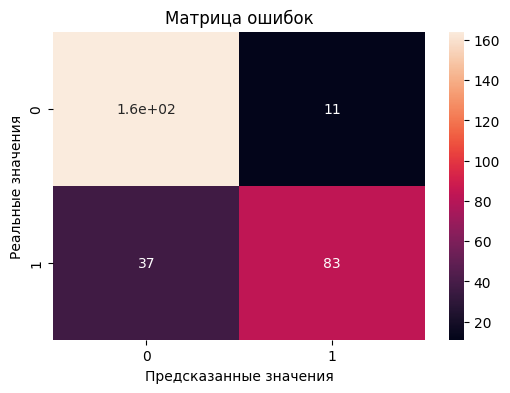

Отчет классификации:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87       175
           1       0.88      0.69      0.78       120

    accuracy                           0.84       295
   macro avg       0.85      0.81      0.82       295
weighted avg       0.84      0.84      0.83       295



In [8]:
print(y_pred.shape, y_test.shape)
vcm(y_pred, y_test)

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [9]:
random_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=50, stop=300, num=6)],
    'max_depth': [5, 10, 15, 20, 30, None],
    'max_leaf_nodes': [10, 20, 30, 40, 50]
}

rf_rcv = RandomizedSearchCV(estimator=model, param_distributions=random_grid, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
rf_rcv.fit(X_train2, y_train)

rcv_best_params = rf_rcv.best_params_
print(f"Лучшие параметры RandomSearchCV: {rcv_best_params}")

Лучшие параметры RandomSearchCV: {'n_estimators': 200, 'max_leaf_nodes': 30, 'max_depth': 10}


#### GridSearchCV

In [10]:
param_grid = {
    'n_estimators': [rcv_best_params['n_estimators'], rcv_best_params['n_estimators'] + 20],
    'max_depth': [rcv_best_params['max_depth']],
    'max_leaf_nodes': [rcv_best_params['max_leaf_nodes'], rcv_best_params['max_leaf_nodes'] + 5]
}

rf_cv = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)
rf_cv.fit(X_train2, y_train)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_

print(f"Итоговые лучшие параметры GridSearchCV: {best_params}")

Итоговые лучшие параметры GridSearchCV: {'max_depth': 10, 'max_leaf_nodes': 30, 'n_estimators': 200}


### 9. Комплексная оценка точности лучшей модели:

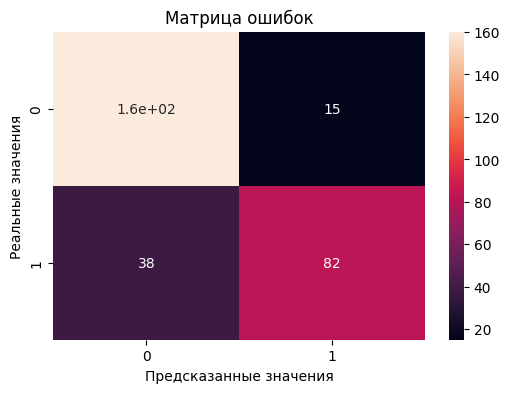

Отчет классификации:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       175
           1       0.85      0.68      0.76       120

    accuracy                           0.82       295
   macro avg       0.83      0.80      0.81       295
weighted avg       0.82      0.82      0.82       295



In [11]:
y_pred_best = best_model.predict(X_test2)
vcm(y_pred_best, y_test)

## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=1),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=1)
}

for name, clf in models.items():
    clf.fit(X_train2, y_train)
    pred = clf.predict(X_test2)
    acc = accuracy_score(y_test, pred)
    print(f"{name} — точность (Accuracy): {acc:.4f}")

Logistic Regression — точность (Accuracy): 0.8169
KNN — точность (Accuracy): 0.6983
Decision Tree — точность (Accuracy): 0.7627


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [13]:
def predict_interactive(model):
    print("Ввод данных пассажира")
    try:
        pclass = int(input("Класс пассажира (1-3): "))
        age = float(input("Возраст (число): "))
        sibsp = int(input("Количество братьев/сестер/супругов на борту: "))
        parch = int(input("Количество родителей/детей на борту: "))
        fare = float(input("Плата за проезд (число): "))

        sex = input("Пол (male/female): ").strip().lower()
        sex_male = True if sex == 'male' else False

        embarked = input("Из какого города отправились (S/C/Q): ").strip().upper()
        embarked_q = True if embarked == 'Q' else False
        embarked_s = True if embarked == 'S' else False

        # Формируем DataFrame в том же формате, что и X_train2
        user_data = pd.DataFrame([{
            'Pclass': pclass, 'Age': age, 'SibSp': sibsp, 'Parch': parch, 'Fare': fare,
            'Sex_male': sex_male, 'Embarked_Q': embarked_q, 'Embarked_S': embarked_s
        }])

        pred = model.predict(user_data)
        if pred[0] == 1:
            print("\nВердикт: Скорее всего, вы бы выжили!")
        else:
            print("\nВердикт: К сожалению, ваши шансы выжить минимальны")

    except ValueError:
        print("\nОшибка: Некорректный ввод! Пожалуйста, вводите числа там, где ожидается число.")

predict_interactive(best_model)

Ввод данных пассажира
Класс пассажира (1-3): 2
Возраст (число): 12
Количество братьев/сестер/супругов на борту: 2
Количество родителей/детей на борту: 2
Плата за проезд (число): 15
Пол (male/female): male
Из какого города отправились (S/C/Q): s

Вердикт: Скорее всего, вы бы выжили!


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [17]:
import kagglehub
import pandas as pd

kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv('/kaggle/input/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv') # если вывел ошибку, запустить еще раз
df = df.head(10000)

Using Colab cache for faster access to the 'sleep-health-and-daily-performance-dataset' dataset.


In [16]:
display(df.head())
display(df.info())
df.describe()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    10000 non-null  int64  
 1   age                          10000 non-null  int64  
 2   gender                       10000 non-null  object 
 3   occupation                   10000 non-null  object 
 4   bmi                          10000 non-null  float64
 5   country                      10000 non-null  object 
 6   sleep_duration_hrs           10000 non-null  float64
 7   sleep_quality_score          10000 non-null  float64
 8   rem_percentage               10000 non-null  float64
 9   deep_sleep_percentage        10000 non-null  float64
 10  sleep_latency_mins           10000 non-null  int64  
 11  wake_episodes_per_night      10000 non-null  int64  
 12  caffeine_mg_before_bed       10000 non-null  int64  
 13  alcohol_units_bef

None

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,34.50170,26.247050,6.412116,4.847570,20.220100,20.293620,19.907600,3.357000,38.867000,...,14.749000,5.771250,7.17126,66.502200,0.557900,0.082300,20.543580,1.212015,58.934170,0.39150
std,2886.89568,10.97685,4.464494,1.283687,1.515894,3.423622,4.246689,7.605804,1.932078,69.651069,...,21.329583,1.602169,3.44792,7.127866,0.496661,0.274835,2.906818,0.786791,22.346157,0.48811
min,1.00000,18.00000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.00000,45.000000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.00000
25%,2500.75000,26.00000,23.200000,5.527500,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.80000,62.000000,0.000000,0.000000,18.400000,0.670000,44.000000,0.00000
50%,5000.50000,33.00000,26.200000,6.340000,4.900000,20.300000,20.400000,20.000000,3.000000,0.000000,...,0.000000,5.900000,7.40000,66.000000,1.000000,0.000000,20.500000,1.210000,59.800000,0.00000
75%,7500.25000,42.00000,29.300000,7.270000,5.900000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.900000,9.70000,71.000000,1.000000,0.000000,22.600000,1.750000,75.400000,1.00000
max,10000.00000,69.00000,44.400000,10.500000,9.600000,30.000000,30.000000,55.000000,8.000000,400.000000,...,108.000000,10.000000,17.30000,93.000000,1.000000,1.000000,28.000000,3.000000,100.000000,1.00000


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from scipy.stats import randint

TARGET = 'cognitive_performance_score'
DROP_COLS = ['person_id', 'country', 'felt_rested', 'sleep_disorder_risk']

X = df.drop(columns=[TARGET] + DROP_COLS, errors='ignore')
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include='number').columns


preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

#RandomizedSearchCV
param_dist = {
    'rf__n_estimators': randint(50, 200),
    'rf__max_depth': randint(3, 12),
    'rf__min_samples_split': randint(5, 20),
    'rf__min_samples_leaf': randint(2, 8),
    'rf__max_features': ['sqrt', 'log2', None]
}

rs = RandomizedSearchCV(pipeline, param_dist, n_iter=25, cv=3,
                        scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)
print(f"RandomSearch | Best MAE: {-rs.best_score_:.4f}")

#GridSearchCV (точечная настройка)
bp = rs.best_params_
param_grid = {
    'rf__n_estimators': [max(50, bp['rf__n_estimators']-50), bp['rf__n_estimators'], bp['rf__n_estimators']+50],
    'rf__max_depth': [max(2, bp['rf__max_depth']-2), bp['rf__max_depth'], bp['rf__max_depth']+2],
    'rf__min_samples_split': [max(2, bp['rf__min_samples_split']-1), bp['rf__min_samples_split'], bp['rf__min_samples_split']+1]
}

gs = GridSearchCV(pipeline, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
gs.fit(X_train, y_train)
print(f"GridSearch   | Best MAE: {-gs.best_score_:.4f}")

y_pred = gs.best_estimator_.predict(X_test)
print(f"\nИтог | R²: {r2_score(y_test, y_pred):.4f} | MAE: {mean_absolute_error(y_test, y_pred):.4f}")

RandomSearch | Best MAE: 5.7189
GridSearch   | Best MAE: 5.6561

Итог | R²: 0.9006 | MAE: 5.5970


In [19]:
gs.best_params_

{'rf__max_depth': 12, 'rf__min_samples_split': 5, 'rf__n_estimators': 222}

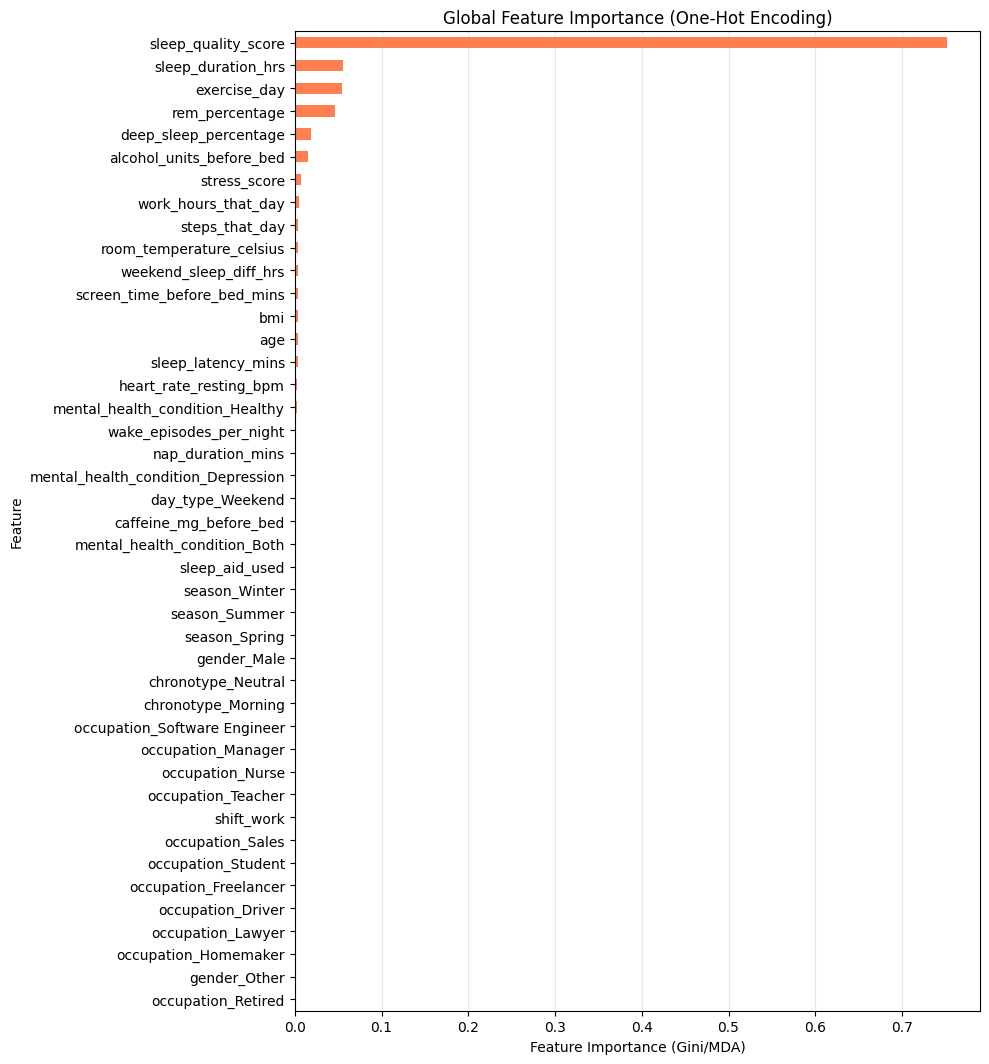

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

best_pipeline = gs.best_estimator_
rf_model = best_pipeline.named_steps['rf']
preprocessor = best_pipeline.named_steps['prep']

importances = rf_model.feature_importances_
raw_names = preprocessor.get_feature_names_out()
feature_names = [n.split('__', 1)[-1] for n in raw_names]

importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)


plt.figure(figsize=(10, max(6, len(feature_names)*0.25)))
importance_df.plot(kind='barh')
plt.xlabel("Feature Importance (Gini/MDA)")
plt.ylabel("Feature")
plt.title("Global Feature Importance (One-Hot Encoding)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [22]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [23]:
import pandas as pd

data = pd.read_csv('data/dog_food.csv')

In [24]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('Spoiled', axis=1), data['Spoiled'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((328, 4), (162, 4))

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [27]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

max_depth = [int(i) for i in np.linspace(start=1, stop=100, num=10)]
max_depth.append(None)
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(estimator=model,param_distributions=param_grid,n_iter=100,cv=5,random_state=42,n_jobs=-1)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
print(f'Лучшая модель: {best_model}')

Лучшая модель: RandomForestClassifier(max_depth=34, max_leaf_nodes=23, n_estimators=455,
                       random_state=42)


In [28]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(max_depth=34, max_leaf_nodes=23, n_estimators=455,
                       random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)
fin = X_test.copy()
fin['Spoiled'] = pred
fin = fin[fin['Spoiled'] != 0]
print("Чем больше значение, тем больше влияние консерванта на партию")
for i in fin.columns:
  if i != 'Spoiled':
    print(f'{i}: {fin[i].sum()}')


Чем больше значение, тем больше влияние консерванта на партию
A: 294
B: 269
C: 615.0
D: 294
